<a href="https://colab.research.google.com/github/simasaadi/toronto-water-analytics/blob/main/02_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Set-Up: Libraries, Style and Access to Cleaned Data

In this notebook I focus on exploratory data analysis (EDA) using the cleaned Toronto AOC1 water-quality dataset created in the previous step.

I first:

- Import core analytical libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) plus `os` and `zipfile` for file handling.
- Apply a consistent plotting style to keep visualizations clean and readable.
- Ensure a `/content/data/cleaned` directory exists in the Colab environment.
- Download the **cleaned dataset ZIP** directly from GitHub (raw link) and unzip it into the cleaned folder.

This makes the notebook fully reproducible: any user can run it from scratch and retrieve the same cleaned dataset from the repository.


In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# 1) Make sure the cleaned data folder exists in Colab
clean_dir = "/content/data/cleaned"
os.makedirs(clean_dir, exist_ok=True)

# 2) URL of your CLEANED ZIP file on GitHub (RAW link)
zip_url = "https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip"

# 3) Where to save the ZIP in Colab
zip_path = f"{clean_dir}/toronto_aoc1_clean.zip"

# 4) Download the ZIP from GitHub into Colab
!wget -O "$zip_path" "$zip_url"

# 5) Unzip the cleaned CSV into the same folder
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(clean_dir)

print("Files in cleaned folder:")
!ls -lh "$clean_dir"


--2025-11-21 05:53:17--  https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17649562 (17M) [application/zip]
Saving to: ‘/content/data/cleaned/toronto_aoc1_clean.zip’

/content/data/clean 100%[===================>]  16.83M  --.-KB/s    in 0.1s    

2025-11-21 05:53:18 (169 MB/s) - ‘/content/data/cleaned/toronto_aoc1_clean.zip’ saved [17649562/17649562]

Files in cleaned folder:
total 248M
-rw-r--r-- 1 root root 231M Nov 21 05:53 toronto_aoc1_clean.csv
-rw-r--r-- 1 root root  17M Nov 21 05:53 toronto_aoc1_clean.zip


### 2. Load the Cleaned Dataset into a DataFrame

Next, I load the cleaned CSV into a pandas DataFrame:

- Use the explicit path to the unzipped file in `/content/data/cleaned`.
- Set `low_memory=False` to allow pandas to infer dtypes more reliably on this large file.
- Confirm the load with a simple shape check to see the number of rows and columns.

This establishes the base DataFrame (`df`) used for all subsequent exploration.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

clean_path = "/content/data/cleaned/toronto_aoc1_clean.csv"

df = pd.read_csv(clean_path)

print("Dataset loaded successfully.")
df.shape


In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# 1) Make sure the cleaned data folder exists in Colab
clean_dir = "/content/data/cleaned"
os.makedirs(clean_dir, exist_ok=True)

# 2) URL of your CLEANED ZIP file on GitHub (RAW link)
zip_url = "https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip"

# 3) Where to save the ZIP in Colab
zip_path = f"{clean_dir}/toronto_aoc1_clean.zip"

# 4) Download the ZIP from GitHub into Colab
!wget -O "$zip_path" "$zip_url"

# 5) Unzip the cleaned CSV into the same folder
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(clean_dir)

print("Files in cleaned folder:")
!ls -lh "$clean_dir"


--2025-11-21 05:53:37--  https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17649562 (17M) [application/zip]
Saving to: ‘/content/data/cleaned/toronto_aoc1_clean.zip’

/content/data/clean 100%[===================>]  16.83M  --.-KB/s    in 0.04s   

2025-11-21 05:53:37 (390 MB/s) - ‘/content/data/cleaned/toronto_aoc1_clean.zip’ saved [17649562/17649562]

Files in cleaned folder:
total 248M
-rw-r--r-- 1 root root 231M Nov 21 05:53 toronto_aoc1_clean.csv
-rw-r--r-- 1 root root  17M Nov 21 05:53 toronto_aoc1_clean.zip


In [ ]:
# Change this name if the CSV inside the zip is slightly different
csv_path = "/content/data/cleaned/toronto_aoc1_clean.csv"

df = pd.read_csv(csv_path, low_memory=False)

print("Dataset loaded successfully.")
df.shape


Dataset loaded successfully.


(770611, 22)

In [ ]:
csv_path = "/content/data/cleaned/toronto_aoc1_clean (1).csv"


### 3. First Glance at the Data

I begin with a quick tabular preview of the dataset using `df.head()`.  

This gives an immediate sense of:

- How the cleaned column names look.
- Example values for locations, characteristics and measurement units.
- How the engineered datetime fields (`activity_datetime`, `year`, `month`, `dayofweek`) appear in the final dataset.


In [ ]:
df.head()


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
0,119886859,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,"Temperature, water",15.0,deg C,Actual,2019-07-25 00:00:00,2019,7,Thursday
1,119886893,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,360.0,uS/cm,Actual,2021-07-15 00:00:00,2021,7,Thursday
2,119886896,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,NaN,pH,7.8,NaN,Actual,2019-07-18 00:00:00,2019,7,Thursday
3,119886916,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,369.0,uS/cm,Actual,2020-09-03 00:00:00,2020,9,Thursday
4,119886936,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,324.0,uS/cm,Actual,2020-09-17 00:00:00,2020,9,Thursday


### 4. Structural and Completeness Checks

To understand data volume and completeness, I perform a few basic checks:

- Report overall shape (rows, columns).
- Inspect column data types to confirm that numeric, datetime and categorical fields are correctly represented.
- Compute missing-value counts per column to identify any remaining gaps.
- Count the number of unique monitoring locations and characteristics.

These diagnostics confirm that the cleaned dataset is large (over 770k records) and rich in both spatial and parameter diversity.


In [ ]:
print("Rows, Columns:", df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values (count):")
print(df.isna().sum())

print("\nUnique Monitoring Locations:", df["monitoringlocationname"].nunique())
print("Unique Characteristics:", df["characteristicname"].nunique())

df.head()


Rows, Columns: (770611, 22)

Column Types:
id                                                         int64
doi                                                       object
datasetname                                               object
monitoringlocationid                                      object
monitoringlocationname                                    object
monitoringlocationlatitude                               float64
monitoringlocationlongitude                              float64
monitoringlocationhorizontalcoordinatereferencesystem     object
monitoringlocationtype                                    object
activitytype                                              object
activitymedianame                                         object
activitystartdate                                         object
activitystarttime                                         object
samplecollectionequipmentname                             object
characteristicname                             

,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
0,119886859,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,"Temperature, water",15.0,deg C,Actual,2019-07-25 00:00:00,2019,7,Thursday
1,119886893,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,360.0,uS/cm,Actual,2021-07-15 00:00:00,2021,7,Thursday
2,119886896,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,NaN,pH,7.8,NaN,Actual,2019-07-18 00:00:00,2019,7,Thursday
3,119886916,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,369.0,uS/cm,Actual,2020-09-03 00:00:00,2020,9,Thursday
4,119886936,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,324.0,uS/cm,Actual,2020-09-17 00:00:00,2020,9,Thursday


### 5. Descriptive Statistics for All Fields

Using `df.describe(include="all")`, I generate high-level descriptive statistics across all columns:

- For numeric columns, I review min, max, quartiles, mean and standard deviation.
- For categorical columns, I look at counts, number of unique values, and most frequent categories.

This step helps surface potential issues such as extreme measurement values, highly skewed distributions, or categories that dominate the dataset.


In [ ]:
df.describe(include="all")


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
count,7.706110e+05,770611,770611,770611,770611,770611.000000,770611.000000,770611,770611,770611,...,728655,755718,770611,770611.000000,727998,770611,770611,770611.000000,770611.000000,770611
unique,NaN,21,21,623,456,NaN,NaN,4,5,5,...,671,6,104,NaN,26,4,17491,NaN,NaN,7
top,NaN,10.25976/tnw0-3x43,Provincial Water Quality Monitoring Network (P...,6007600602,"Credit River : Highway 10 Dnstr.Orangeville, ,...",NaN,NaN,UNKWN,River/Stream,Sample-Routine,...,6:02:00,Water Bottle,"Total Phosphorus, mixed forms",NaN,mg/L,Actual,1995-07-31 06:02:00,NaN,NaN,Wednesday
freq,NaN,628164,628164,29060,29060,NaN,NaN,634005,632502,681547,...,336269,706306,34537,NaN,457470,750864,920,NaN,NaN,195624
mean,3.558854e+08,NaN,NaN,NaN,NaN,43.775240,-79.655380,NaN,NaN,NaN,...,NaN,NaN,NaN,161.514551,NaN,NaN,NaN,1998.481454,6.552931,NaN
std,7.022804e+07,NaN,NaN,NaN,NaN,0.137264,0.304139,NaN,NaN,NaN,...,NaN,NaN,NaN,1701.890167,NaN,NaN,NaN,16.416244,3.282715,NaN
min,2.438245e+07,NaN,NaN,NaN,NaN,43.530483,-80.182397,NaN,NaN,NaN,...,NaN,NaN,NaN,-892.000000,NaN,NaN,NaN,1964.000000,1.000000,NaN
25%,3.827541e+08,NaN,NaN,NaN,NaN,43.650753,-79.930998,NaN,NaN,NaN,...,NaN,NaN,NaN,0.440000,NaN,NaN,NaN,1985.000000,4.000000,NaN
50%,3.846648e+08,NaN,NaN,NaN,NaN,43.779877,-79.633273,NaN,NaN,NaN,...,NaN,NaN,NaN,7.600000,NaN,NaN,NaN,2000.000000,7.000000,NaN
75%,3.865775e+08,NaN,NaN,NaN,NaN,43.888462,-79.421410,NaN,NaN,NaN,...,NaN,NaN,NaN,75.100000,NaN,NaN,NaN,2015.000000,9.000000,NaN


### 6. Parameter-Level Summary (Characteristics)

To understand which parameters drive most of the observations, I aggregate measurements by `characteristicname`:

- Compute count, mean, standard deviation, minimum and maximum `resultvalue` for each characteristic.
- Sort by measurement count to highlight the most commonly monitored parameters.

This summary reveals the core water-quality indicators (e.g., total phosphorus, conductivity, chloride, temperature, dissolved oxygen) and shows how their value ranges differ.


In [ ]:
characteristic_summary = (
    df.groupby("characteristicname")["resultvalue"]
      .agg(["count", "mean", "std", "min", "max"])
      .sort_values("count", ascending=False)
)

characteristic_summary.head(10)


,count,mean,std,min,max
characteristicname,,,,,
"Total Phosphorus, mixed forms",34537,80.147583,1116.801522,0.000500,50654.0
Specific conductance,34337,1037.920159,1205.853918,0.000000,36900.0
Chloride,30382,178.187815,3034.519852,0.000000,525500.0
"Temperature, water",28989,11.059386,8.176320,-45.000000,173.0
Kjeldahl nitrogen,28531,1.711418,22.549975,0.005000,2465.0
Dissolved oxygen (DO),28265,10.451679,9.254271,-0.016255,999.0
Nitrite,26159,0.064699,0.219464,0.000000,7.5
Orthophosphate,25211,66.561591,980.836331,0.000000,51634.0
Total suspended solids,24236,104.532781,715.508748,0.000000,39168.0


### 7. Location-Level Summary

I repeat a similar aggregation at the monitoring-location level:

- Group by `monitoringlocationname`.
- Compute count, mean, standard deviation, minimum and maximum `resultvalue`.
- Sort by count to see which sites are sampled most frequently.

This helps identify high-priority locations (high sampling intensity) and provides an initial sense of which sites tend to have higher or more variable measurements.


In [ ]:
location_summary = (
    df.groupby("monitoringlocationname")["resultvalue"]
      .agg(["count", "mean", "std", "min", "max"])
      .sort_values("count", ascending=False)
)

location_summary.head(10)


,count,mean,std,min,max
monitoringlocationname,,,,,
"Credit River : Highway 10 Dnstr.Orangeville, ,1St Crossin",29060,123.673324,333.566168,-29.90,10654.0
"Credit River : Highpoint Sideroad, Dwnstr,Dam At Melvill",28906,124.883895,354.114983,-41.50,9748.0
"Don River : Pottery Rd, Toronto",26397,428.260375,6973.418626,-164.00,680000.0
"Humber River : Old Mill Rd, Etobicoke",25370,204.017424,3546.342632,-65.10,290000.0
"Credit River : Hwy 10, Dwnstr Orangeville, ,2Nd Crossin",18119,130.193481,369.062183,-16.70,9318.0
Credit River : Southern Dam Of Orangeville Reservoir,18059,79.761837,320.356515,-9.71,18987.0
Silver Creek : Highway 7 Norval,17161,129.263968,462.851599,-71.30,32000.0
Credit River : Highway 7 Norval,16866,96.629253,304.792402,-17.50,13000.0
"Black Creek : Glen Lawson Rd, Upstrm Limehouse",15646,141.562274,513.156797,-38.10,46000.0


### 8. Distribution of Measurement Values (Raw vs. Log Scale)

Water-quality measurements are often heavily skewed due to occasional extreme events.  
To visualize this, I examine the distribution of `resultvalue` in two ways:

- A standard histogram to show the raw distribution.
- A second histogram using a **logarithmic x-axis** to better reveal the structure of the right tail.

Comparing these views confirms that the dataset contains a long tail of very large values, motivating an explicit treatment of outliers.


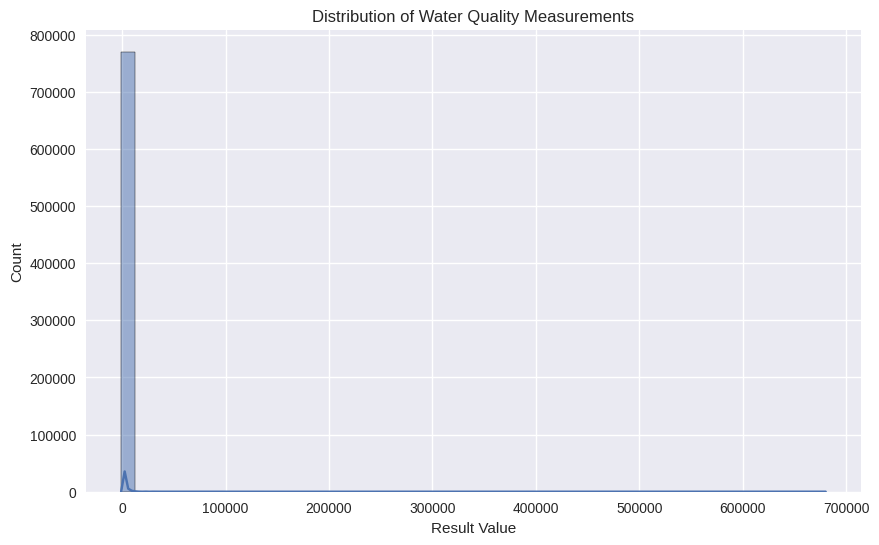

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df["resultvalue"], kde=True, bins=50)
plt.title("Distribution of Water Quality Measurements")
plt.xlabel("Result Value")
plt.ylabel("Count")
plt.show()


### 9. Impact of Extreme Outliers (Top 1%)

To quantify the effect of extreme values, I:

- Compute the 99th percentile of `resultvalue`.
- Create a trimmed dataset (`df_trim`) that excludes the top 1% of measurements.
- Compare row counts before and after trimming.
- Plot a new histogram on the trimmed data.

This provides a clearer view of the main body of the distribution while documenting exactly how many records are affected by outlier removal.


In [ ]:
metric_col = "resultvalue"  # this is the numeric column we care about

# Remove top 1% extreme outliers
upper_limit = df[metric_col].quantile(0.99)
df_trimmed = df[df[metric_col] <= upper_limit]

print("Old count:", len(df))
print("New count after trimming:", len(df_trimmed))
print("Upper 1% cutoff:", upper_limit)


Old count: 770611
New count after trimming: 762934
Upper 1% cutoff: 1820.0


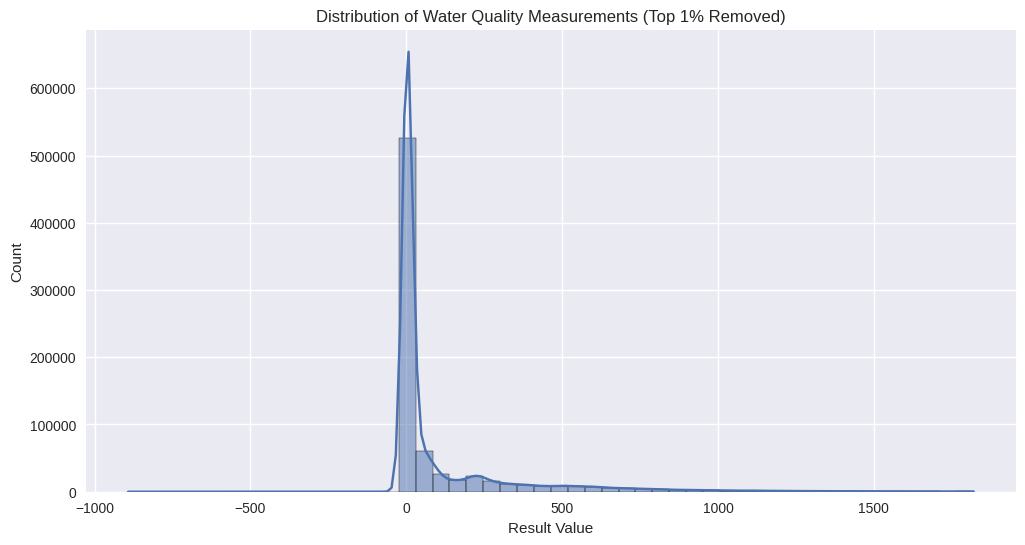

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_trimmed[metric_col], bins=50, kde=True)
plt.title("Distribution of Water Quality Measurements (Top 1% Removed)")
plt.xlabel("Result Value")
plt.ylabel("Count")
plt.show()


### 10. Boxplot of Result Values

I use a boxplot to visualize the distribution of `resultvalue` and highlight potential outliers:

- The box shows the inter-quartile range (IQR).
- Whiskers indicate the range of typical values.
- Individual points beyond the whiskers show extreme measurements.

This complements the histogram views and makes it easy to see how concentrated most values are relative to a small number of very large observations.


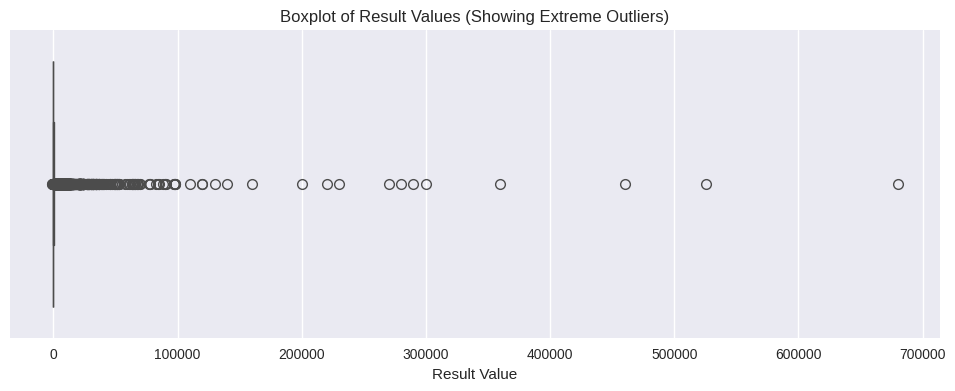

In [ ]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df[metric_col])
plt.title("Boxplot of Result Values (Showing Extreme Outliers)")
plt.xlabel("Result Value")
plt.show()


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770611 entries, 0 to 770610
Data columns (total 22 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   id                                                     770611 non-null  int64  
 1   doi                                                    770611 non-null  object 
 2   datasetname                                            770611 non-null  object 
 3   monitoringlocationid                                   770611 non-null  object 
 4   monitoringlocationname                                 770611 non-null  object 
 5   monitoringlocationlatitude                             770611 non-null  float64
 6   monitoringlocationlongitude                            770611 non-null  float64
 7   monitoringlocationhorizontalcoordinatereferencesystem  770611 non-null  object 
 8   monitoringlocationtype            

In [ ]:
df.describe(include='all')


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
count,7.706110e+05,770611,770611,770611,770611,770611.000000,770611.000000,770611,770611,770611,...,728655,755718,770611,770611.000000,727998,770611,770611,770611.000000,770611.000000,770611
unique,NaN,21,21,623,456,NaN,NaN,4,5,5,...,671,6,104,NaN,26,4,17491,NaN,NaN,7
top,NaN,10.25976/tnw0-3x43,Provincial Water Quality Monitoring Network (P...,6007600602,"Credit River : Highway 10 Dnstr.Orangeville, ,...",NaN,NaN,UNKWN,River/Stream,Sample-Routine,...,6:02:00,Water Bottle,"Total Phosphorus, mixed forms",NaN,mg/L,Actual,1995-07-31 06:02:00,NaN,NaN,Wednesday
freq,NaN,628164,628164,29060,29060,NaN,NaN,634005,632502,681547,...,336269,706306,34537,NaN,457470,750864,920,NaN,NaN,195624
mean,3.558854e+08,NaN,NaN,NaN,NaN,43.775240,-79.655380,NaN,NaN,NaN,...,NaN,NaN,NaN,161.514551,NaN,NaN,NaN,1998.481454,6.552931,NaN
std,7.022804e+07,NaN,NaN,NaN,NaN,0.137264,0.304139,NaN,NaN,NaN,...,NaN,NaN,NaN,1701.890167,NaN,NaN,NaN,16.416244,3.282715,NaN
min,2.438245e+07,NaN,NaN,NaN,NaN,43.530483,-80.182397,NaN,NaN,NaN,...,NaN,NaN,NaN,-892.000000,NaN,NaN,NaN,1964.000000,1.000000,NaN
25%,3.827541e+08,NaN,NaN,NaN,NaN,43.650753,-79.930998,NaN,NaN,NaN,...,NaN,NaN,NaN,0.440000,NaN,NaN,NaN,1985.000000,4.000000,NaN
50%,3.846648e+08,NaN,NaN,NaN,NaN,43.779877,-79.633273,NaN,NaN,NaN,...,NaN,NaN,NaN,7.600000,NaN,NaN,NaN,2000.000000,7.000000,NaN
75%,3.865775e+08,NaN,NaN,NaN,NaN,43.888462,-79.421410,NaN,NaN,NaN,...,NaN,NaN,NaN,75.100000,NaN,NaN,NaN,2015.000000,9.000000,NaN


In [ ]:
df.head(10)


,id,doi,datasetname,monitoringlocationid,monitoringlocationname,monitoringlocationlatitude,monitoringlocationlongitude,monitoringlocationhorizontalcoordinatereferencesystem,monitoringlocationtype,activitytype,...,activitystarttime,samplecollectionequipmentname,characteristicname,resultvalue,resultunit,resultvaluetype,activity_datetime,year,month,dayofweek
0,119886859,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,"Temperature, water",15.0,deg C,Actual,2019-07-25 00:00:00,2019,7,Thursday
1,119886893,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,360.0,uS/cm,Actual,2021-07-15 00:00:00,2021,7,Thursday
2,119886896,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,NaN,pH,7.8,NaN,Actual,2019-07-18 00:00:00,2019,7,Thursday
3,119886916,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,369.0,uS/cm,Actual,2020-09-03 00:00:00,2020,9,Thursday
4,119886936,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,324.0,uS/cm,Actual,2020-09-17 00:00:00,2020,9,Thursday
5,119886985,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,315.0,uS/cm,Actual,2020-08-20 00:00:00,2020,8,Thursday
6,119887005,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Test strip,Chlorine,0.0,ppm,Actual,2020-08-05 00:00:00,2020,8,Wednesday
7,119887017,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,"Temperature, water",15.0,deg C,Actual,2020-07-29 00:00:00,2020,7,Wednesday
8,119887026,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,Probe/Sensor,Conductivity,354.0,uS/cm,Actual,2020-08-05 00:00:00,2020,8,Wednesday
9,119887027,10.25976/zqwq-zh61,Swim Drink Fish Toronto Community Monitoring Hubs,4544,Lake Ontario:Humber Bay West Park,43.61564,-79.47722,UNKWN,Lake/Pond,Field Msr/Obs,...,0:00:00,NaN,pH,7.2,NaN,Actual,2019-06-20 00:00:00,2019,6,Thursday


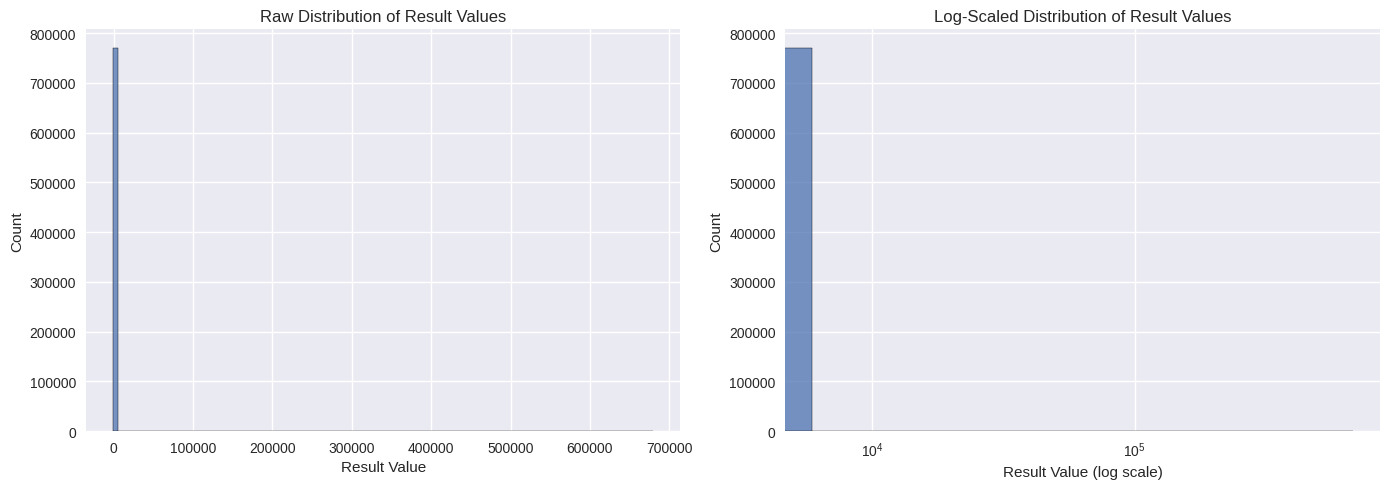

In [ ]:
metric_col = "resultvalue"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(df[metric_col], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Raw Distribution of Result Values")
axes[0].set_xlabel("Result Value")
axes[0].set_ylabel("Count")

# Log-scaled distribution (handles extreme skew)
sns.histplot(df[metric_col], bins=100, kde=False, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Log-Scaled Distribution of Result Values")
axes[1].set_xlabel("Result Value (log scale)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


Original rows: 770611
After removing top 1%: 762934
99th percentile: 1820.0


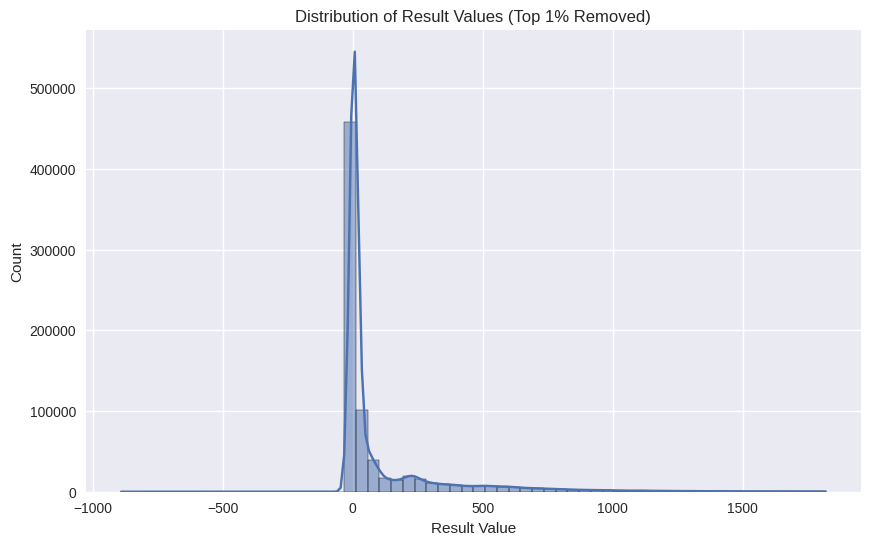

In [ ]:
upper_1pct = df[metric_col].quantile(0.99)
df_trim = df[df[metric_col] <= upper_1pct].copy()

print("Original rows:", len(df))
print("After removing top 1%:", len(df_trim))
print("99th percentile:", upper_1pct)

plt.figure(figsize=(10, 6))
sns.histplot(df_trim[metric_col], bins=60, kde=True)
plt.title("Distribution of Result Values (Top 1% Removed)")
plt.xlabel("Result Value")
plt.ylabel("Count")
plt.show()


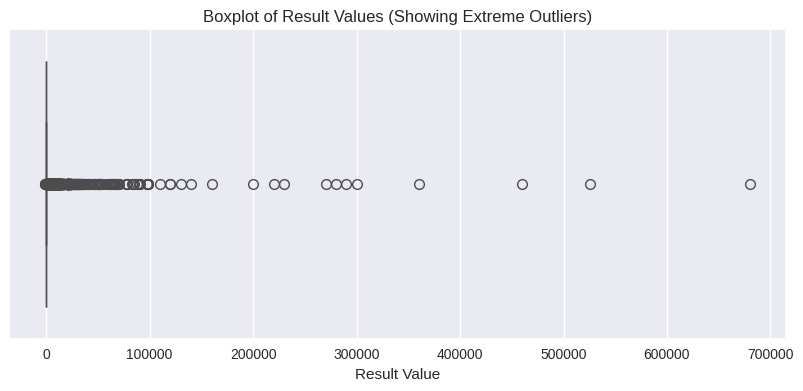

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[metric_col])
plt.title("Boxplot of Result Values (Showing Extreme Outliers)")
plt.xlabel("Result Value")
plt.show()


### 12. Monthly Trend in Mean Result Values

I compute a **monthly time series** of mean `resultvalue` across all characteristics and locations:

- Resample the dataset at a monthly frequency using `activity_datetime` as the index.
- Calculate the average measurement per month.
- Plot the resulting time series.

This gives a high-level view of how overall water-quality measurements evolve through time and whether there are long-term trends or structural breaks.


In [ ]:
df["activity_datetime"] = pd.to_datetime(df["activity_datetime"], errors="coerce")
df["date"] = df["activity_datetime"].dt.date


/tmp/ipython-input-2571711987.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["resultvalue"]


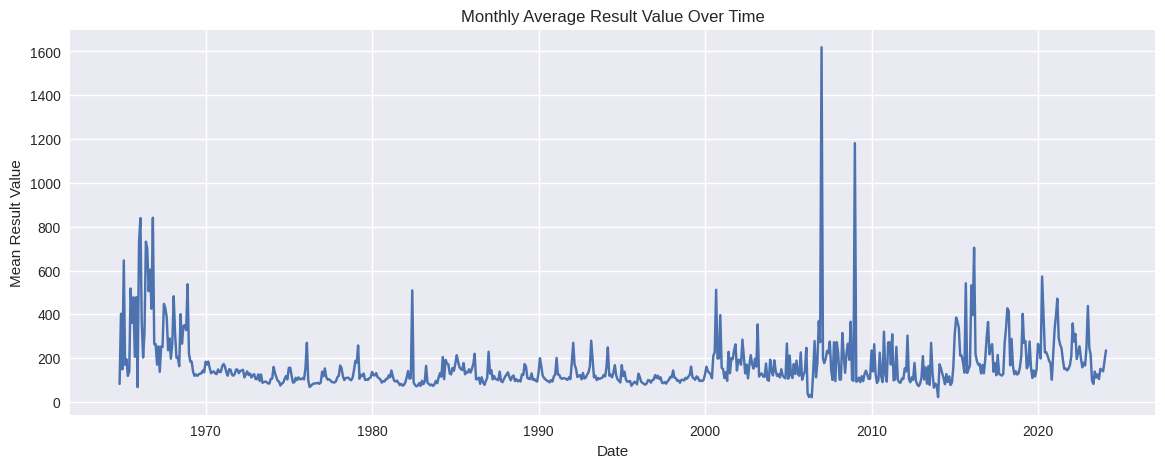

In [ ]:
monthly = (
    df.set_index("activity_datetime")
      .resample("M")["resultvalue"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x="activity_datetime", y="resultvalue")
plt.title("Monthly Average Result Value Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Result Value")
plt.show()


### 13. Yearly Trends by Top Characteristics

To drill down into parameter-specific dynamics, I focus on the **top 4 most frequently measured characteristics**:

- Identify the most common `characteristicname` values.
- Group by `year` and `characteristicname` and compute the **median** `resultvalue` for each combination.
- Plot yearly median trends for each top characteristic on the same chart.

Using the median reduces the influence of extreme outliers and makes it easier to compare long-term patterns across parameters.


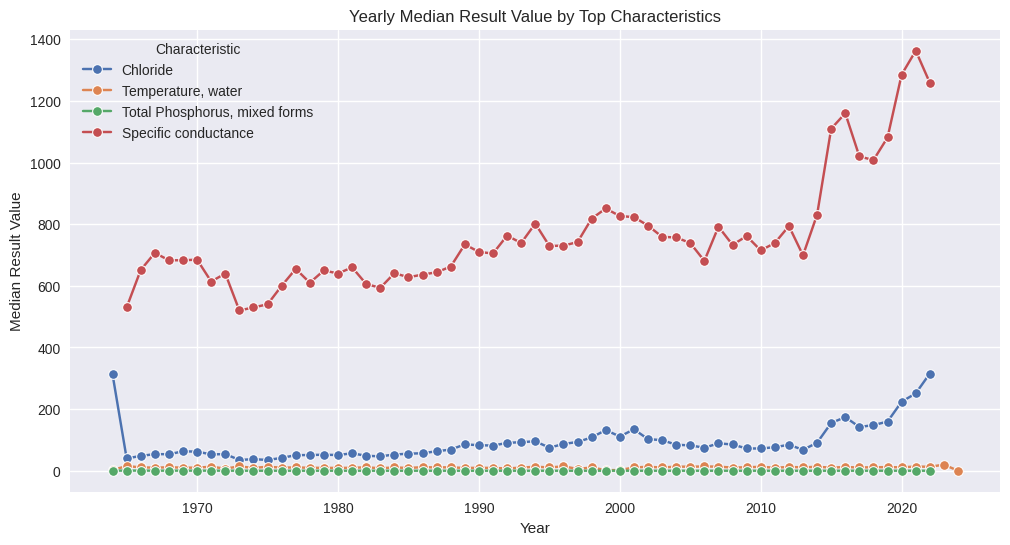

In [ ]:
top_chars = df["characteristicname"].value_counts().head(4).index

yearly_char = (
    df[df["characteristicname"].isin(top_chars)]
    .groupby(["year", "characteristicname"])["resultvalue"]
    .median()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_char,
    x="year",
    y="resultvalue",
    hue="characteristicname",
    marker="o"
)
plt.title("Yearly Median Result Value by Top Characteristics")
plt.xlabel("Year")
plt.ylabel("Median Result Value")
plt.legend(title="Characteristic")
plt.show()


### 14. Seasonal Pattern by Month

Next, I explore intra-annual (seasonal) variation:

- Group measurements by `month` (1–12) across all years.
- Compute the median `resultvalue` for each month.
- Plot the resulting seasonal profile.

This reveals whether water-quality measurements tend to be higher or lower in specific seasons, which can reflect hydrological cycles, temperature effects, or human activity patterns.


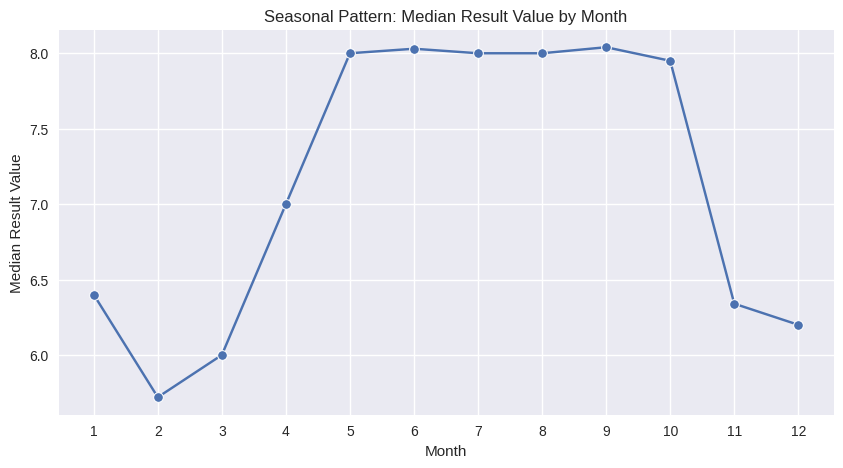

In [ ]:
monthly_season = (
    df.groupby("month")["resultvalue"]
      .median()
      .reset_index()
      .sort_values("month")
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_season, x="month", y="resultvalue", marker="o")
plt.title("Seasonal Pattern: Median Result Value by Month")
plt.xlabel("Month")
plt.ylabel("Median Result Value")
plt.xticks(range(1, 13))
plt.show()


### 15. Spatial Pattern: Monitoring Locations Coloured by Mean Value

To visualize spatial patterns, I aggregate measurements at the monitoring-location level:

- Compute the mean `resultvalue` for each unique combination of location ID, name, latitude and longitude.
- Plot the sites on a simple scatter map (longitude vs. latitude), using colour to represent the mean measurement level.

Although this is not a full GIS map, it provides a quick visual indication of **hotspots** and relatively **cleaner** areas across the monitored region.


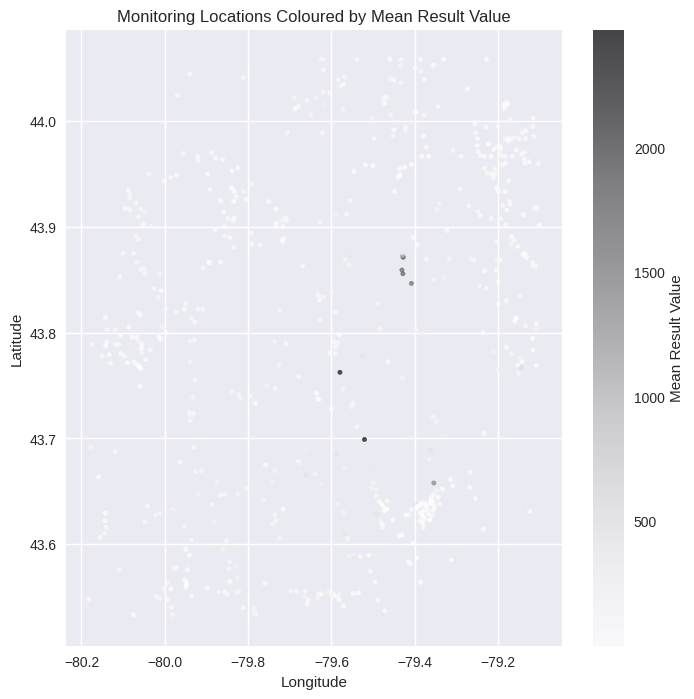

In [ ]:
location_means = (
    df.groupby(
        ["monitoringlocationid", "monitoringlocationname",
         "monitoringlocationlatitude", "monitoringlocationlongitude"]
    )["resultvalue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 8))
plt.scatter(
    location_means["monitoringlocationlongitude"],
    location_means["monitoringlocationlatitude"],
    c=location_means["resultvalue"],
    s=10,
    alpha=0.7
)
plt.colorbar(label="Mean Result Value")
plt.title("Monitoring Locations Coloured by Mean Result Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### 16. Ranking Locations by Median Result Value

Finally, I rank sites by their typical measurement levels:

- Group by `monitoringlocationname` and compute the **median** `resultvalue` per site.
- Sort locations in descending order and take the top 10.
- Plot a horizontal bar chart of these locations and their median values.

This ranking highlights which monitoring sites consistently report higher measurements and may warrant further investigation or visual deep-dives in subsequent dashboards or reports.


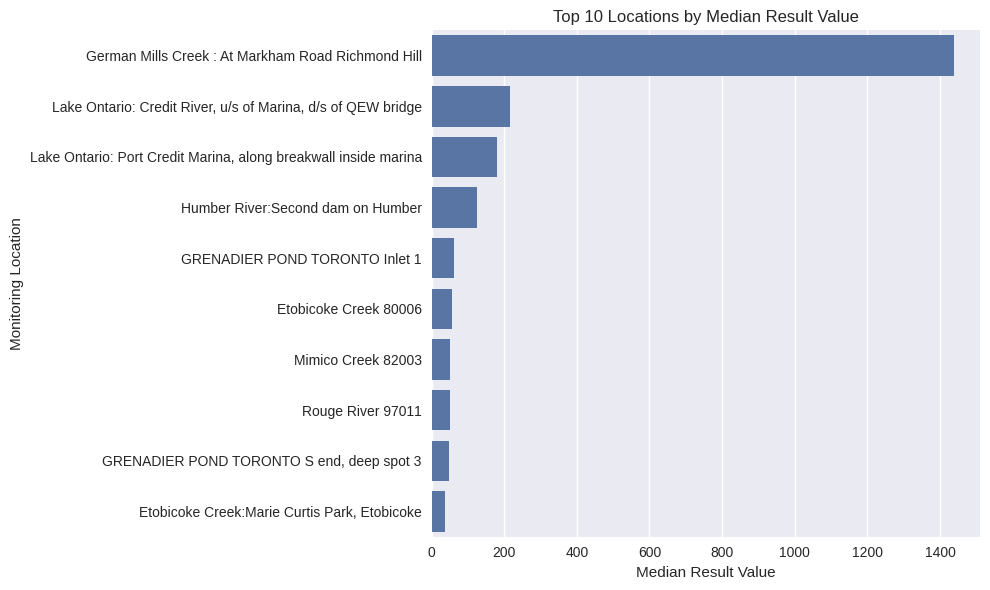

In [ ]:
loc_rank = (
    df.groupby("monitoringlocationname")["resultvalue"]
      .median()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=loc_rank,
    y="monitoringlocationname",
    x="resultvalue"
)
plt.title("Top 10 Locations by Median Result Value")
plt.xlabel("Median Result Value")
plt.ylabel("Monitoring Location")
plt.tight_layout()
plt.show()
